<a href="https://colab.research.google.com/github/msatyasambhav-beep/Python-For-AI-ML/blob/main/Outliers_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

3 - Sigma Technique

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statistics
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data = pd.read_csv('raw_sales2.csv')

In [6]:
data.head(5)

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [7]:
type(data)

pandas.core.frame.DataFrame

In [8]:
data.head(5)

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [11]:
# Function to Detection Outlier on one-dimentional datasets.
def find_anomalies(data):
    #define a list to accumlate anomalies
    anomalies = []

    # Set upper and lower limit to 3 standard deviation
    random_data_std = statistics.stdev(data)
    random_data_mean = statistics.mean(data)
    # 3-standard deviation

    anomaly_cut_off = random_data_std * 3

    lower_limit  = random_data_mean - anomaly_cut_off
    upper_limit = random_data_mean + anomaly_cut_off

    # Generate outliers
    for outlier in data:
        if outlier > upper_limit or outlier < lower_limit:
            anomalies.append(outlier)
    return anomalies

In [12]:
data.price

,price
0,525000
1,290000
2,328000
3,380000
4,310000
...,...
29575,500000
29576,560000
29577,464950
29578,589000


In [13]:
list_1 = find_anomalies(data['price'])

In [14]:
len(list_1)

461

In [15]:
data.price.skew()

np.float64(4.312009366902366)

In [16]:
import seaborn as sns

<Axes: xlabel='price', ylabel='Density'>

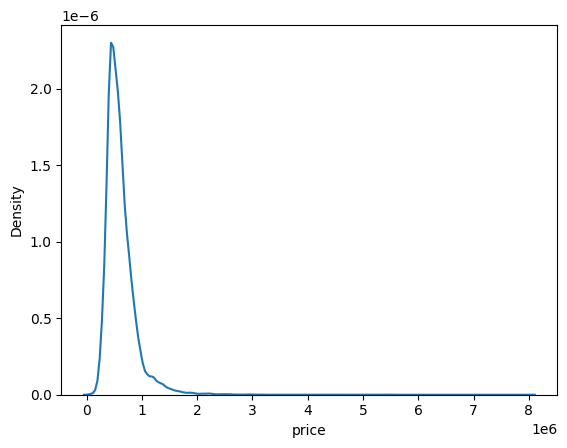

In [17]:
sns.kdeplot(data.price)

In [23]:
data['price_transformed'] = np.log(data.price)

In [24]:
data.price_transformed.skew()

np.float64(0.4731646269984763)

In [25]:
list_2 = find_anomalies(data.price_transformed)

In [26]:
len(list_2)

266

<Axes: xlabel='price_transformed', ylabel='Density'>

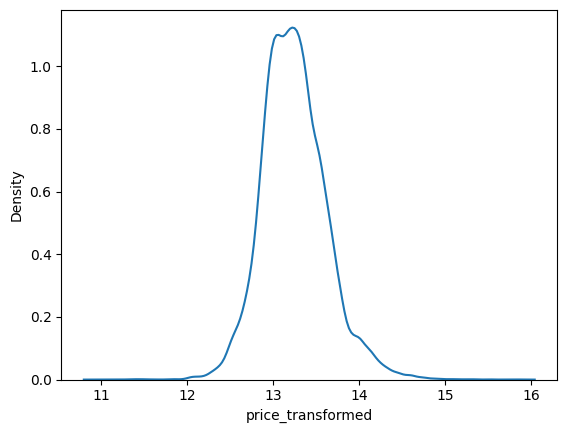

In [27]:
sns.kdeplot(data.price_transformed)

In [30]:
data['price_transformed_double'] = np.log(data.price_transformed)

In [31]:
data['price_transformed_double'].skew()

np.float64(0.33092530655758573)

In [33]:
list_3 = find_anomalies(data.price_transformed_double)

In [34]:
len(list_3)

251

In [35]:
len(data)

29580

Anything below 40, or above 80 are consider as outliers

BOXPLOT

<Axes: >

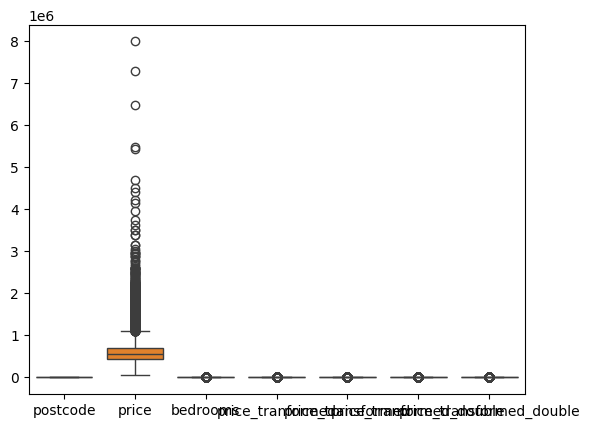

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=data)


The above code display the plot below

as you can see it considers everything above 75 or below ~-35 to be an outliner

In [39]:
import pandas as pd
df = pd.DataFrame(data)

In [40]:
df.describe()

,postcode,price,bedrooms,price_tranformed,price_transformed,price_tranformed_double,price_transformed_double
count,29580.000000,2.958000e+04,29580.000000,29580.000000,29580.000000,29580.000000,29580.000000
mean,2730.249730,6.097363e+05,3.250169,13.244695,13.244695,2.583199,2.583199
std,146.717292,2.817079e+05,0.951275,0.375214,0.375214,0.028183,0.028183
min,2600.000000,5.650000e+04,0.000000,10.941996,10.941996,2.392608,2.392608
25%,2607.000000,4.400000e+05,3.000000,12.994530,12.994530,2.564529,2.564529
50%,2615.000000,5.500000e+05,3.000000,13.217674,13.217674,2.581555,2.581555
75%,2905.000000,7.050000e+05,4.000000,13.465953,13.465953,2.600165,2.600165
max,2914.000000,8.000000e+06,5.000000,15.894952,15.894952,2.766002,2.766002


Inter Quartile Range

In [44]:
list1 = [43, 54, 56, 61, 62, 66, 68, 69, 69, 70, 71, 72, 77, 78, 79, 85, 87, 88, 89, 93, 95, 96, 98, 99, 99]

In [45]:
len(list1)

25

In [46]:
max(list1)

99

In [47]:
min(list1)

43

In [48]:
import statistics

statistics.mean(list1)

76.96

In [49]:
sorted(list1)

[43,
 54,
 56,
 61,
 62,
 66,
 68,
 69,
 69,
 70,
 71,
 72,
 77,
 78,
 79,
 85,
 87,
 88,
 89,
 93,
 95,
 96,
 98,
 99,
 99]

to find the 90 th percentile for these ordered scores , start by multiplying 90 percent times the total number of  which gives 90% ∗ 25 = 0.90 ∗ 25 = 22.5 (the index). Rounding up to the nearest whole number, you get 23.

In [52]:
list2 = sorted(list1)

Hence, 98 is the 90th percentile for this dataset

Now say you want to find the 20th percentile. Start by taking 0.20 x 25 = 5 (the index); this is a whole number, which tells you the 20th percentile is the average of the 5th and 6th values in the ordered data set (62 and 66).

so, 20th percentile is 62+66/2 = 64

The median (the 50th percentile) for the test scores is the 13th score: 77.